# Sentiment Classification of Movie Reviews

In [1]:
import nltk
import numpy as np
import pandas as pd

from nltk.corpus import movie_reviews

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier

#Download dataset if not already present
nltk.download('movie_reviews')

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


True

## LOAD DATA

In [2]:
#Convert documents to raw text format
fileids = movie_reviews.fileids()
X = [movie_reviews.raw(fileids=[f]) for f in fileids]

#Create binary labels
y = np.array(["pos" if f.startswith("pos") else "neg" for f in fileids])

print("Total documents:",len(X))
print("Class distribution:",pd.Series(y).value_counts())

Total documents: 2000
Class distribution: neg    1000
pos    1000
Name: count, dtype: int64


## CONSISTENT VALIDATION PROTOCOL

In [3]:
from nltk.classify.decisiontree import f
#Use stratified 5-fold cross validation for fair comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(pipeline, X, y, model_name):
  """
  Evaluates a pipeline using 5-fold stratified cross validation.
  Returns mean accuracy.
  """
  scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
  print(f"{model_name} | Accuracy:{scores.mean():.4f}(+/-{scores.std():.4f})")
  return scores.mean()

## BASELINE MODEL
## TF-IDF + LOGISTIC REGRESSION

In [4]:
baseline_pipeline = Pipeline([
    ("vectorizer",TfidfVectorizer()),
    ("classifier",LogisticRegression(max_iter=2000))
])

baseline_score=evaluate_model(baseline_pipeline,X,y,"Baseline(TF-IDF + LR)")

Baseline(TF-IDF + LR) | Accuracy:0.8240(+/-0.0139)


## PREPROCESSING EXPERIMENTS

In [5]:
#TF vs TF-IDF
tf_pipeline = Pipeline([
    ("vectorizer",CountVectorizer()),
    ("classifier",LogisticRegression(max_iter=2000))
])

evaluate_model(tf_pipeline,X,y,"TF + LR")
evaluate_model(baseline_pipeline,X,y,"TF-IDF + LR")

#Stop-word Removal ON/OFF
stop_pipeline = Pipeline([
    ("vectorizer",TfidfVectorizer(stop_words="english")),
    ("classifier",LogisticRegression(max_iter=2000))
])

evaluate_model(stop_pipeline,X,y,"TF-IDF + Stop-words Removed")

#Unigrams vs Unigrams and Bigrams
bigram_pipeline = Pipeline([
    ("vectorizer",TfidfVectorizer(ngram_range=(1,2))),
    ("classifier",LogisticRegression(max_iter=2000))
])

evaluate_model(bigram_pipeline,X,y,"TF-IDF + Unigrams and Bigrams")

TF + LR | Accuracy:0.8345(+/-0.0206)
TF-IDF + LR | Accuracy:0.8240(+/-0.0139)
TF-IDF + Stop-words Removed | Accuracy:0.8175(+/-0.0106)
TF-IDF + Unigrams and Bigrams | Accuracy:0.8045(+/-0.0175)


np.float64(0.8045)

## FEATURE SELECTION EXPERIMENTS

In [6]:
#Frequency Based Selection (Top N Features)
freq_pipeline_3000 = Pipeline([
    ("vectorizer",TfidfVectorizer(max_features=3000)),
    ("classifier",LogisticRegression(max_iter=2000))
])

freq_pipeline_7000 = Pipeline([
    ("vectorizer",TfidfVectorizer(max_features=7000)),
    ("classifier",LogisticRegression(max_iter=2000))
])

evaluate_model(freq_pipeline_3000,X,y,"Top 3000 Features")
evaluate_model(freq_pipeline_7000,X,y,"Top 7000 Features")

#Mutual Information Based Feature Selection
mi_pipeline = Pipeline([
    ("vectorizer",CountVectorizer()),
    ("feature_selection",SelectKBest(mutual_info_classif,k=7000)),
    ("classifier",LogisticRegression(max_iter=2000))
    ])

evaluate_model(mi_pipeline,X,y,"Mutual Information (Top 7000)")

Top 3000 Features | Accuracy:0.8235(+/-0.0150)
Top 7000 Features | Accuracy:0.8210(+/-0.0163)
Mutual Information (Top 7000) | Accuracy:0.8355(+/-0.0168)


np.float64(0.8355)

## CLASSIFIER COMPARISON

In [7]:
#Naive-Bayes (Multinomial)
nb_pipeline = Pipeline([
    ("vectorizer",TfidfVectorizer()),
    ("classifier",MultinomialNB())
])

evaluate_model(nb_pipeline,X,y,"Multinomial NB")

#Logistic Regression (Different C Values)
for C_val in [0.1, 1, 10]:
  lr_pipeline = Pipeline([
      ("vectorizer",TfidfVectorizer()),
      ("classifier",LogisticRegression(C=C_val,max_iter=2000))
  ])
  evaluate_model(lr_pipeline,X,y,f"Logistic Regression (C={C_val})")

#Linear SVM (Different C Values)
for C_val in [0.1, 1, 10]:
  svm_pipeline = Pipeline([
      ("vectorizer",TfidfVectorizer()),
      ("classifier",LinearSVC(C=C_val))
  ])
  evaluate_model(svm_pipeline,X,y,f"Linear SVM (C={C_val})")

Multinomial NB | Accuracy:0.8115(+/-0.0137)
Logistic Regression (C=0.1) | Accuracy:0.7925(+/-0.0088)
Logistic Regression (C=1) | Accuracy:0.8240(+/-0.0139)
Logistic Regression (C=10) | Accuracy:0.8435(+/-0.0168)
Linear SVM (C=0.1) | Accuracy:0.8215(+/-0.0133)
Linear SVM (C=1) | Accuracy:0.8465(+/-0.0140)
Linear SVM (C=10) | Accuracy:0.8500(+/-0.0092)


## ENSEMBLE METHOD

In [8]:
#Define base models
lr_model=LogisticRegression(max_iter=2000)
nb_model=MultinomialNB()
svm_model=LinearSVC(C=1)

ensemble_pipeline = Pipeline([
    ("vectorizer",TfidfVectorizer(ngram_range=(1,2),max_features=7000)),
    ("classifier",VotingClassifier(
        estimators=[
        ("lr",lr_model),
        ("nb",nb_model),
        ("svm",svm_model)
        ],
        voting="hard"
    ))
])

evaluate_model(ensemble_pipeline,X,y,"Voting Ensemble")

Voting Ensemble | Accuracy:0.8410(+/-0.0166)


np.float64(0.841)

## RESULT PLOTS

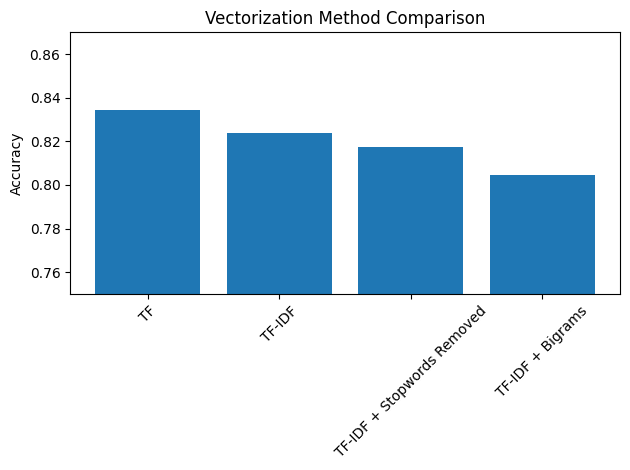

In [9]:
import matplotlib.pyplot as plt

# Vectorization results
methods = [
    "TF",
    "TF-IDF",
    "TF-IDF + Stopwords Removed",
    "TF-IDF + Bigrams"
]

accuracies = [0.8345, 0.8240, 0.8175, 0.8045]

plt.figure()
plt.bar(methods, accuracies)
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Vectorization Method Comparison")
plt.ylim(0.75, 0.87)
plt.tight_layout()
plt.show()

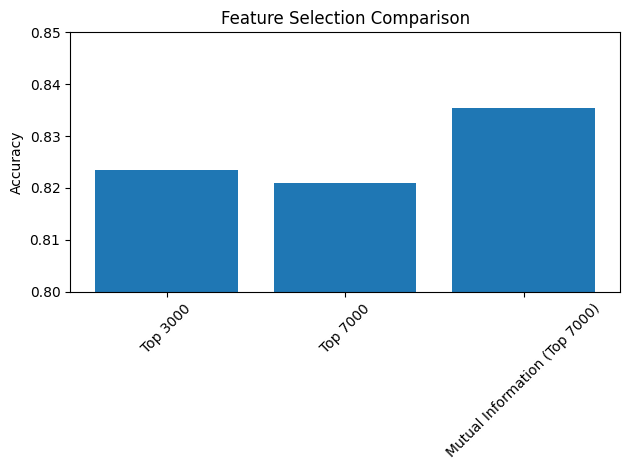

In [10]:
import matplotlib.pyplot as plt

# Feature selection results
methods = [
    "Top 3000",
    "Top 7000",
    "Mutual Information (Top 7000)"
]

accuracies = [0.8235, 0.8210, 0.8355]

plt.figure()
plt.bar(methods, accuracies)
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Feature Selection Comparison")
plt.ylim(0.80, 0.85)
plt.tight_layout()
plt.show()

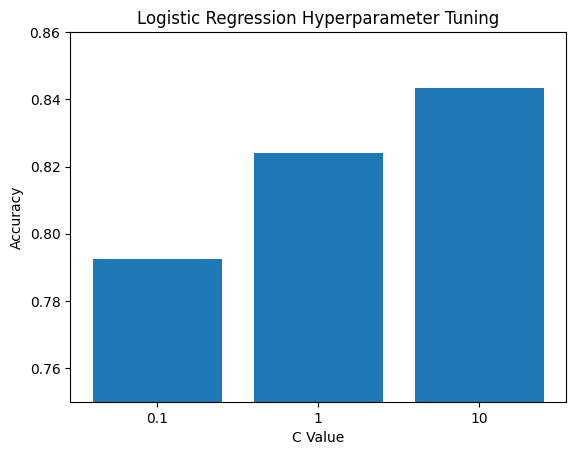

In [11]:
import matplotlib.pyplot as plt

# Logistic Regression results
C_values = ["0.1", "1", "10"]
accuracies = [0.7925, 0.8240, 0.8435]

plt.figure()
plt.bar(C_values, accuracies)
plt.xlabel("C Value")
plt.ylabel("Accuracy")
plt.title("Logistic Regression Hyperparameter Tuning")
plt.ylim(0.75, 0.86)
plt.show()

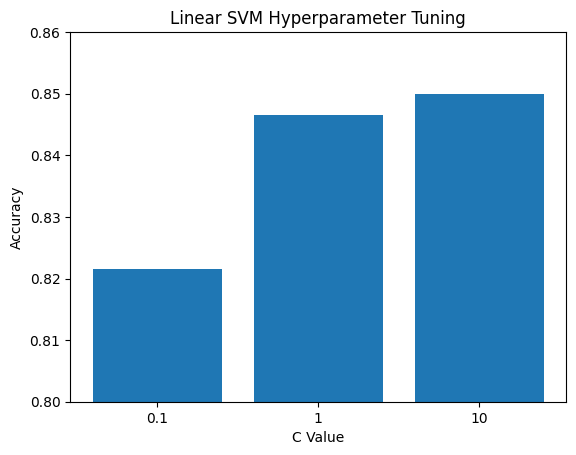

In [12]:
import matplotlib.pyplot as plt

# Linear SVM results
C_values = ["0.1", "1", "10"]
accuracies = [0.8215, 0.8465, 0.8500]

plt.figure()
plt.bar(C_values, accuracies)
plt.xlabel("C Value")
plt.ylabel("Accuracy")
plt.title("Linear SVM Hyperparameter Tuning")
plt.ylim(0.80, 0.86)
plt.show()

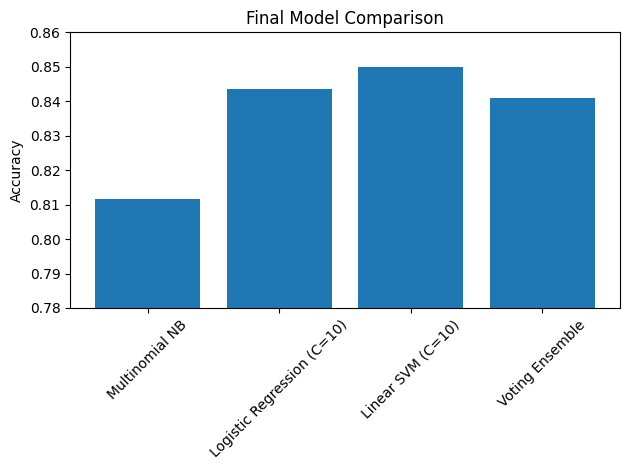

In [13]:
import matplotlib.pyplot as plt

models = [
    "Multinomial NB",
    "Logistic Regression (C=10)",
    "Linear SVM (C=10)",
    "Voting Ensemble"
]

accuracies = [0.8115, 0.8435, 0.8500, 0.8410]

plt.figure()
plt.bar(models, accuracies)
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Final Model Comparison")
plt.ylim(0.78, 0.86)
plt.tight_layout()
plt.show()